### import

In [1]:
import sys
print(sys.executable)
!{sys.executable} -m pip install xgboost
!{sys.executable} -m pip install pandas seaborn matplotlib scikit-learn
!{sys.executable} -m pip install mlxtend

c:\Users\Abdel\AppData\Local\Programs\Python\Python314\python.exe



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: c:\Users\Abdel\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: c:\Users\Abdel\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: c:\Users\Abdel\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [21]:
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

In [ ]:
%pip install torch
import torch 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torch import optim
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.metrics import mean_squared_error
pd.set_option("display.max_columns", None)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: c:\Users\Abdel\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


Preprocessing Done! Shape: (163912, 17)
Missing values: 2709


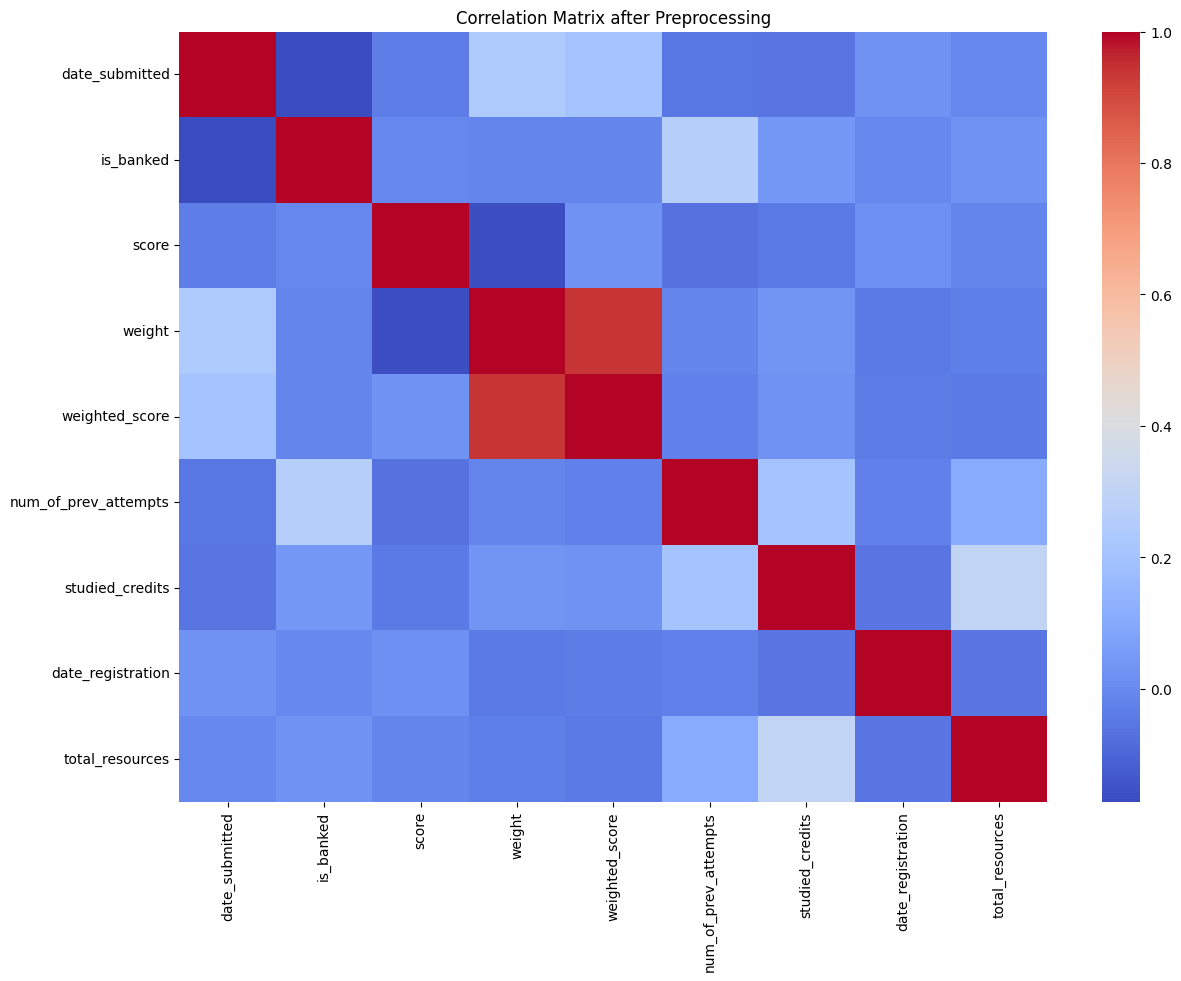

In [4]:
assessments = pd.read_csv("assessments.csv")
courses = pd.read_csv("courses.csv")
student_info = pd.read_csv("studentInfo.csv")
student_assessments = pd.read_csv("StudentAssesments.csv")
student_registration = pd.read_csv("studentRegistration.csv")
vle = pd.read_csv("vle.csv")

# replace unknown values
student_info.replace("?", np.nan, inplace=True)
student_registration.replace("?", np.nan, inplace=True)
assessments.replace("?", np.nan, inplace=True)
# vle.replace('?', np.nan, inplace=True)

# grouping the vle by code_module and code_presentation to get the total resources for each course presentation
vle_features = (
    vle.groupby(["code_module", "code_presentation"])
    .size()
    .reset_index(name="total_resources")
)

# merge student_assessments with assessments to get the weight of each assessment and calculate the weighted score
df_marks = pd.merge(student_assessments, assessments, on="id_assessment")

df_marks["score"] = df_marks["score"].replace("?", "0")
df_marks["weight"] = df_marks["weight"].replace("?", "0")
df_marks["date_submitted"] = df_marks["date_submitted"].replace("?", "0")

df_marks["score"] = df_marks["score"].replace("", "0")
df_marks["weight"] = df_marks["weight"].replace("", "0")
df_marks["date_submitted"] = df_marks["date_submitted"].replace("", "0")

# convert to numeric values
df_marks["score"] = df_marks["score"].astype(float)
df_marks["weight"] = df_marks["weight"].astype(float)
# give weight to score and calulate it
df_marks["weighted_score"] = (df_marks["score"] * df_marks["weight"]) / 100


df = pd.merge(
    df_marks, student_info, on=["id_student", "code_module", "code_presentation"]
)
df = pd.merge(
    df,
    student_registration[
        ["id_student", "code_module", "code_presentation", "date_registration"]
    ],
    on=["id_student", "code_module", "code_presentation"],
    how="left",
)
df = pd.merge(df, vle_features, on=["code_module", "code_presentation"], how="left")

# handle missing values
df["date_registration"] = pd.to_numeric(df["date_registration"], errors="coerce")
df["date_registration"] = df["date_registration"].fillna(0)
df["imd_band"] = df["imd_band"].fillna(df["imd_band"].mode()[0])
df["total_resources"] = df["total_resources"].fillna(0)

# drop uncessary columns
drop_cols = ["id_student", "id_assessment", "code_module", "code_presentation"]
final_df = df.drop(columns=drop_cols)

# Scaling
scaler = StandardScaler()
numeric_features = ["date_registration", "weight", "total_resources", "date_submitted"]
final_df[numeric_features] = scaler.fit_transform(final_df[numeric_features])

# Heat map
print(f"Preprocessing Done! Shape: {final_df.shape}")
print(f"Missing values: {final_df.isnull().sum().sum()}")

plt.figure(figsize=(14, 10))
correlation_matrix = final_df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm")
plt.title("Correlation Matrix after Preprocessing")
plt.show()

final_df.to_csv("Preprocessed_Data.csv", index=False)

### load data

In [5]:
df = pd.read_csv("Preprocessed_Data.csv")

In [6]:
df.head()

,date_submitted,is_banked,score,assessment_type,date,weight,weighted_score,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,date_registration,total_resources
0,-1.329140,0,78.0,CMA,18.0,-0.600725,1.56,F,Ireland,A Level or Equivalent,20-30%,0-35,0,30,N,1.104772,-0.909855
1,1.664887,0,65.0,CMA,241.0,-0.712365,0.00,M,London Region,Lower Than A Level,70-80%,0-35,0,120,N,0.870779,0.773297
2,1.273145,0,41.0,TMA,207.0,0.404033,8.20,M,Wales,A Level or Equivalent,40-50%,0-35,0,90,N,-0.341729,0.846797
3,-0.000016,0,15.0,TMA,116.0,0.124933,2.25,M,North Western Region,A Level or Equivalent,20-30%,0-35,0,60,N,0.275161,0.596896
4,0.769477,0,80.0,TMA,173.0,-0.712365,0.00,F,Yorkshire Region,A Level or Equivalent,50-60%,0-35,0,30,N,0.360249,-1.541956


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 163912 entries, 0 to 163911
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   date_submitted        163912 non-null  float64
 1   is_banked             163912 non-null  int64  
 2   score                 163912 non-null  float64
 3   assessment_type       163912 non-null  str    
 4   date                  161203 non-null  float64
 5   weight                163912 non-null  float64
 6   weighted_score        163912 non-null  float64
 7   gender                163912 non-null  str    
 8   region                163912 non-null  str    
 9   highest_education     163912 non-null  str    
 10  imd_band              163912 non-null  str    
 11  age_band              163912 non-null  str    
 12  num_of_prev_attempts  163912 non-null  int64  
 13  studied_credits       163912 non-null  int64  
 14  disability            163912 non-null  str    
 15  date_regist

### pre-processing

In [8]:
df.replace("?", np.nan, inplace=True)
df.replace("", "0", inplace=True)

,date_submitted,is_banked,score,assessment_type,date,weight,weighted_score,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,date_registration,total_resources
0,-1.329140,0,78.0,CMA,18.0,-0.600725,1.56,F,Ireland,A Level or Equivalent,20-30%,0-35,0,30,N,1.104772,-0.909855
1,1.664887,0,65.0,CMA,241.0,-0.712365,0.00,M,London Region,Lower Than A Level,70-80%,0-35,0,120,N,0.870779,0.773297
2,1.273145,0,41.0,TMA,207.0,0.404033,8.20,M,Wales,A Level or Equivalent,40-50%,0-35,0,90,N,-0.341729,0.846797
3,-0.000016,0,15.0,TMA,116.0,0.124933,2.25,M,North Western Region,A Level or Equivalent,20-30%,0-35,0,60,N,0.275161,0.596896
4,0.769477,0,80.0,TMA,173.0,-0.712365,0.00,F,Yorkshire Region,A Level or Equivalent,50-60%,0-35,0,30,N,0.360249,-1.541956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163907,-0.279832,0,85.0,TMA,96.0,0.683132,21.25,F,West Midlands Region,A Level or Equivalent,70-80%,0-35,0,90,Y,-0.916074,1.339247
163908,0.685532,0,86.0,TMA,166.0,0.850592,24.08,M,Scotland,A Level or Equivalent,90-100%,0-35,1,60,N,-0.171552,-1.703656
163909,0.573606,0,99.0,CMA,236.0,-0.712365,0.00,M,North Region,Post Graduate Qualification,30-40%,35-55,0,90,N,0.721875,1.339247
163910,-0.251850,0,30.0,TMA,94.0,0.683132,7.50,M,South West Region,Lower Than A Level,30-40%,0-35,0,150,N,-1.469148,0.773297


In [9]:
# df[["score", "date_registration", "date_unregistration", "date"]] = (
#     df[["score", "date_registration", "date_unregistration", "date"]]
#     .fillna(0)
#     .astype("int32")
# )

df[["date"]] = df[["date"]].fillna(0).astype("int32")
df[["imd_band", "age_band", "highest_education"]].fillna(
    df["imd_band"].mode()[0], inplace=True
)
df["weight"].fillna(df["weight"].mean(), inplace=True)

C:\Users\Abdel\AppData\Local\Temp\ipykernel_21608\731990174.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[["imd_band", "age_band", "highest_education"]].fillna(
C:\Users\Abdel\AppData\Local\Temp\ipykernel_21608\731990174.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained as

0        -0.600725
1        -0.712365
2         0.404033
3         0.124933
4        -0.712365
            ...   
163907    0.683132
163908    0.850592
163909   -0.712365
163910    0.683132
163911    0.683132
Name: weight, Length: 163912, dtype: float64

In [10]:
# cat_col=df.columns[df.dtypes == object]
# num_col=df.columns[df.dtypes != object]

In [11]:
df["imd_band"].replace({"10-20": "10-20%"}, inplace=True)
imd_order = {
    "0-10%": 0,
    "0-10": 0,
    "10-20%": 1,
    "10-20": 1,
    "20-30%": 2,
    "20-30": 2,
    "30-40%": 3,
    "30-40": 3,
    "40-50%": 4,
    "40-50": 4,
    "50-60%": 5,
    "50-60": 5,
    "60-70%": 6,
    "60-70": 6,
    "70-80%": 7,
    "70-80": 7,
    "80-90%": 8,
    "80-90": 8,
    "90-100%": 9,
    "90-100": 9,
}
education_order = {
    "No Formal quals": 0,
    "Lower Than A Level": 1,
    "A Level or Equivalent": 2,
    "HE Qualification": 3,
    "Post Graduate Qualification": 4,
}
age_order = {"0-35": 0, "35-55": 1, "55<=": 2}

df["highest_education"] = df["highest_education"].map(education_order)
df["imd_band"] = df["imd_band"].map(imd_order)
df["age_band"] = df["age_band"].map(age_order)

C:\Users\Abdel\AppData\Local\Temp\ipykernel_21608\2017299988.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["imd_band"].replace({"10-20": "10-20%"}, inplace=True)


In [12]:
# df["region"] = df["region"].str.replace(" ", "_")

df = pd.get_dummies(df, columns=["gender"], drop_first=True)
df = pd.get_dummies(df, columns=["assessment_type"], drop_first=True)
df = pd.get_dummies(df, columns=["disability"], drop_first=True)
# df = pd.get_dummies(df, columns=["region"], drop_first=True)

In [13]:
# df.drop(columns='region',inplace=True)
le = LabelEncoder()
df[ "region"] = le.fit_transform(df["region"])

In [14]:
target = "score"
y = df[target]
X = df.drop(columns=target)

In [15]:
# X.isna().sum()

In [16]:
print(X.isnull().sum())
print(X.head()) 

date_submitted          0
is_banked               0
date                    0
weight                  0
weighted_score          0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
date_registration       0
total_resources         0
gender_M                0
assessment_type_Exam    0
assessment_type_TMA     0
disability_Y            0
dtype: int64
   date_submitted  is_banked  date    weight  weighted_score  region  \
0       -1.329140          0    18 -0.600725            1.56       2   
1        1.664887          0   241 -0.712365            0.00       3   
2        1.273145          0   207  0.404033            8.20      10   
3       -0.000016          0   116  0.124933            2.25       5   
4        0.769477          0   173 -0.712365            0.00      12   

   highest_education  imd_band  age_band  num_of_prev_attempts  \
0                  2         2         0      

In [17]:
mi_scores = mutual_info_regression(X, y)
'studied_credits',

correlations = df.corr()[target].drop(target)
selected = correlations[correlations.abs() > 0.05].index
X_selected = df[selected]
corr_features = list(X_selected.columns)

mi_features = list(X.columns[mi_scores > 0.01])
features_list = list(set(mi_features).union(corr_features))
features_list = mi_features

X = X[features_list]

In [29]:
X_train, X_test,y_train, y_test = train_test_split(X,y , random_state=104, test_size=0.25, shuffle=True)
base_models = {
    #"Linear Regression": LinearRegression(),
   "Random Forest": RandomForestRegressor(n_estimators=200,random_state=42,max_depth=10,min_samples_split=5,min_samples_leaf=2),
    "XGBoost": XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42, verbosity=0),
    #"Ridge": make_pipeline(StandardScaler(), Ridge())
    #"MLP Adam": MLPRegressor(solver='adam', max_iter=1000, random_state=42),
}


scoring = ["r2", "neg_mean_squared_error"]
results = {}

print("\n" + "=" * 55)
print(f"{'Model':<22} {'R²':>8} {'MSE':>10}{'RMSE':>10}")
print("=" * 55)
# models = {
#    **base_models,
#    "Stacking": StackingRegressor(
#     estimators=list(base_models.items()),
#      final_estimator=RandomForestRegressor()
#   )
#}
for name, model in base_models.items():
    cv = cross_validate(model, X_train, y_train, cv=5, scoring=scoring, return_train_score=False)
    r2 = cv["test_r2"].mean()
    mse = -cv["test_neg_mean_squared_error"].mean()
    rmse = np.sqrt(-cv["test_neg_mean_squared_error"].mean())
    results[name] = {"R2": r2, "RMSE": rmse}
    print(f"{name:<22} {r2:>8.4f} {mse:>10.4f} {rmse:>10.4f}")

print("=" * 55)




Model                        R²        MSE      RMSE
Random Forest            0.7816    78.3661     8.8525
XGBoost                  0.7909    75.0405     8.6626


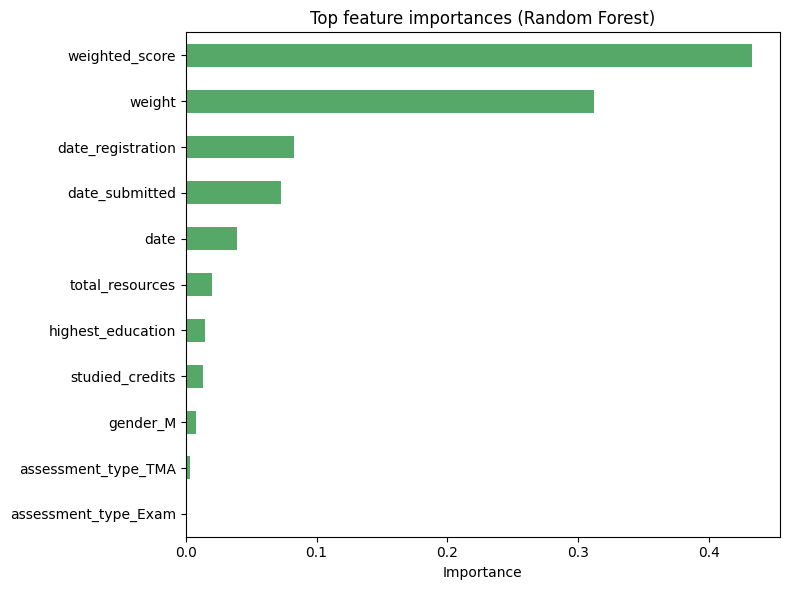

In [24]:

# --- Feature importance from Random Forest ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

importance = (
    pd.Series(rf_model.feature_importances_, index=features_list)
    .sort_values(ascending=True)
    .tail(15)
)

plt.figure(figsize=(8, 6))
importance.plot(kind="barh", color="#55A868")
plt.title("Top feature importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
selected_features=['date_submitted',
 'date',
 'weight',
 'weighted_score',
 'date_registration',
 'total_resources','studied_credits',]



In [32]:
ypred=rf_model.predict(X_test)
mse = mean_squared_error(y_test, ypred)
accuracy = rf_model.score(X_test, y_test)
print(f"Test MSE: {mse:.4f}")
print(f"Test R²: {accuracy:.4f}")

Test MSE: 19.4768
Test R²: 0.9454
